# Unit 5 - Data Preparation (MNIST)

trains a **Generative Adversarial Network** on MNIST handwritten digits.

A GAN has no encoder and no reconstruction target — the *generator* must conjure
images from random noise alone. The only thing it ever learns about the real data
is a verdict from the *discriminator*.

We will normalize images to **`[-1, 1]`** because the generator's last layer is a `tanh` (output range `[-1, 1]`). Real and fake images must live on the *same* scale or the discriminator's job becomes easy. We download MNIST; the `[-1, 1]` transform is applied.

In [2]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print(f"torch {torch.__version__}")

torch 2.10.0+cu128


## 1. Download MNIST

torchvision caches the dataset. We only need the **training split** —
a GAN learns the data distribution; it never evaluates on a held-out test set the way
a classifier does.

In [3]:
train_dataset = datasets.MNIST(
    root="./data/", train=True, download=True, transform=transforms.ToTensor()
)
img0, _ = train_dataset[0]
print(f"Training images: {len(train_dataset)}")
print(f"Image shape:     {tuple(img0.shape)}  (1 channel, 28x28)")
print(f"Pixel range:     [{img0.min():.2f}, {img0.max():.2f}]  (ToTensor gives [0, 1])")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]


Training images: 60000
Image shape:     (1, 28, 28)  (1 channel, 28x28)
Pixel range:     [0.00, 1.00]  (ToTensor gives [0, 1])


## 2. Visualize

64 real digits from real (underlying or unknown) distribution

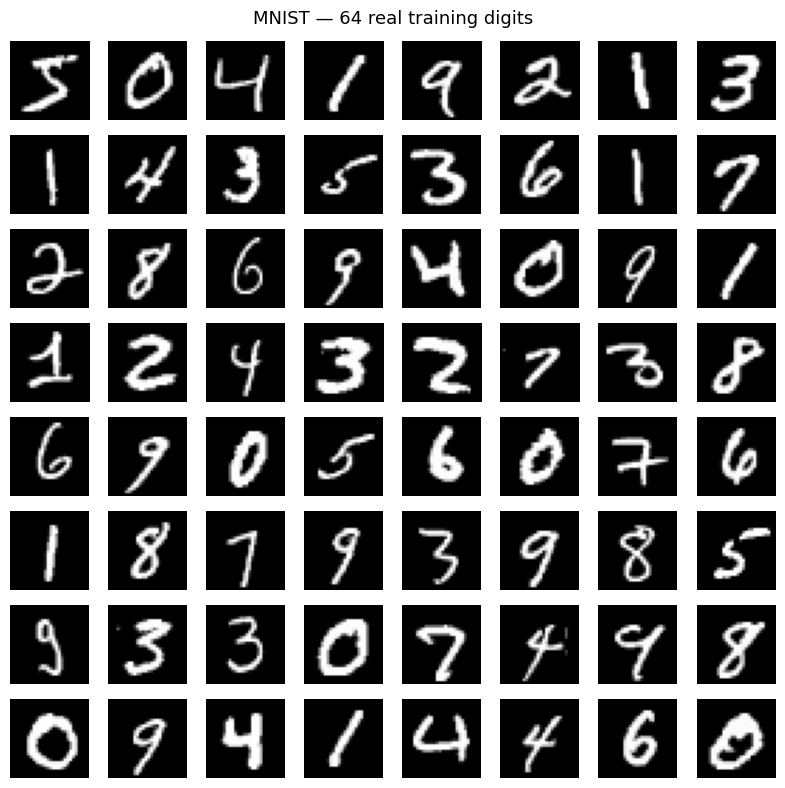

In [4]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for ax, idx in zip(axes.flat, range(64)):
    img, label = train_dataset[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("MNIST — 64 real training digits", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Class balance

A quick check. MNIST is close to uniform across the 10 digits, so a healthy
generator should eventually produce all ten. If it gets stuck on a few, that is
**mode collapse**

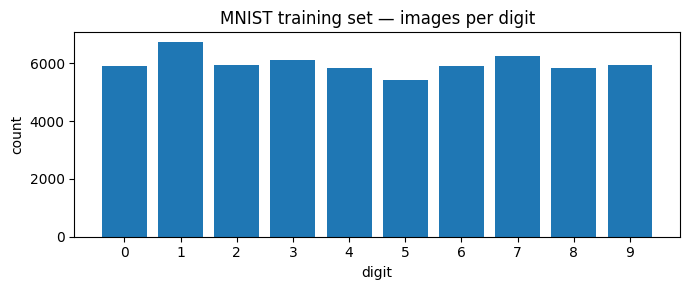

Roughly uniform — a healthy generator should reproduce all 10 digits.


In [5]:
counts = torch.bincount(train_dataset.targets)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(10), counts.numpy())
ax.set_xticks(range(10))
ax.set_xlabel("digit"); ax.set_ylabel("count")
ax.set_title("MNIST training set — images per digit")
plt.tight_layout()
plt.show()
print("Roughly uniform — a healthy generator should reproduce all 10 digits.")